
1. Initial Setup and Data Loading
The dataset consists of two files: adult.data (training) and adult.test (testing). We will merge them for a unified cleaning process, ensuring we handle the formatting differences (such as the trailing period in the test labels).

In [1]:

# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 180)

def show_plot():
    plt.tight_layout()
    plt.show()


In [ ]:
2.Column names
Adult dataset has no header row, so we define them ourselves.

In [2]:

COLUMNS = [
    "age","workclass","fnlwgt","education","education_num",
    "marital_status","occupation","relationship","race","sex",
    "capital_gain","capital_loss","hours_per_week","native_country","income"
]


In [ ]:
3) File paths 

In [10]:

# CHANGE THESE to your local paths (raw string is important on Windows)
train_path = Path(r"C:\suchi\ML-assignment\adult\original _Adult_Data\adult.data")
test_path  = Path(r"C:\suchi\ML-assignment\adult\original _Adult_Data\adult.test")

# Quick safety check
print("Train exists:", train_path.exists(), train_path)
print("Test  exists:", test_path.exists(), test_path)


Train exists: True C:\suchi\ML-assignment\adult\original _Adult_Data\adult.data
Test  exists: True C:\suchi\ML-assignment\adult\original _Adult_Data\adult.test


In [ ]:
4) Load RAW train + RAW test (Before Cleaning)
  "?" placeholders (missing values)
  extra spaces in categories
  in test file: income labels often have a dot like <=50K.
  adult.test has a header line → we skip it using skiprows=1   


In [11]:

df_train_raw = pd.read_csv(train_path, names=COLUMNS, skipinitialspace=False)
df_test_raw  = pd.read_csv(test_path,  names=COLUMNS, skiprows=1, skipinitialspace=False)

print("Train RAW shape:", df_train_raw.shape)
print("Test  RAW shape:", df_test_raw.shape)

#df_train_raw.head(10)



Train RAW shape: (32561, 15)
Test  RAW shape: (16281, 15)


In [ ]:
5) Combine FIRST (RAW combined dataset)
Now we combine train + test before cleaning.

In [12]:

combined_raw = pd.concat([df_train_raw, df_test_raw], ignore_index=True)
print("Combined RAW shape:", combined_raw.shape)

combined_raw.head(10)


Combined RAW shape: (48842, 15)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
5,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K
6,49,Private,160187,9th,5,Married-spouse-absent,Other-service,Not-in-family,Black,Female,0,0,16,Jamaica,<=50K
7,52,Self-emp-not-inc,209642,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,45,United-States,>50K
8,31,Private,45781,Masters,14,Never-married,Prof-specialty,Not-in-family,White,Female,14084,0,50,United-States,>50K
9,42,Private,159449,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,5178,0,40,United-States,>50K


In [ ]:
5.1 What looks not right in RAW?
    We display a few example values to spot:
    - leading spaces
    - '?' placeholders
    - income labels with '.'

In [13]:

for col in ["workclass", "occupation", "native_country", "income"]:
    examples = pd.Series(combined_raw[col].astype(str).unique()).head(20).tolist()
    print(f"\n{col} examples (RAW):")
    print(examples)



workclass examples (RAW):
[' State-gov', ' Self-emp-not-inc', ' Private', ' Federal-gov', ' Local-gov', ' ?', ' Self-emp-inc', ' Without-pay', ' Never-worked']

occupation examples (RAW):
[' Adm-clerical', ' Exec-managerial', ' Handlers-cleaners', ' Prof-specialty', ' Other-service', ' Sales', ' Craft-repair', ' Transport-moving', ' Farming-fishing', ' Machine-op-inspct', ' Tech-support', ' ?', ' Protective-serv', ' Armed-Forces', ' Priv-house-serv']

native_country examples (RAW):
[' United-States', ' Cuba', ' Jamaica', ' India', ' ?', ' Mexico', ' South', ' Puerto-Rico', ' Honduras', ' England', ' Canada', ' Germany', ' Iran', ' Philippines', ' Italy', ' Poland', ' Columbia', ' Cambodia', ' Thailand', ' Ecuador']

income examples (RAW):
[' <=50K', ' >50K', ' <=50K.', ' >50K.']


In [ ]:
5.2 Count "?" placeholders (RAW)
    Why clean this "?"
    Because "?" is not real data — it means missing values.

In [14]:

def count_q(series):
    return (series.astype(str).str.strip() == "?").sum()

q_counts = pd.Series({c: count_q(combined_raw[c]) for c in combined_raw.columns}).sort_values(ascending=False)
q_counts[q_counts > 0]


occupation        2809
workclass         2799
native_country     857
dtype: int64

In [ ]:
6) Start cleaning (Parse properly)
   Now we reload both files using:
   na_values="?" → converts (?) into real missing values NaN
   skipinitialspace=True → removes spaces after commas
   Then we combine again into one dataset to clean.

In [16]:

train = pd.read_csv(train_path, names=COLUMNS, na_values="?", skipinitialspace=True)
test  = pd.read_csv(test_path,  names=COLUMNS, skiprows=1, na_values="?", skipinitialspace=True)

df = pd.concat([train, test], ignore_index=True)
df_original = df.copy(deep=True)  # ✅ real copy for before/after comparisons

print("Combined parsed shape:", df.shape)
df.head()


Combined parsed shape: (48842, 15)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [ ]:
6.1 Missing values after parsing (NaN) 
    Why clean NaN?
    Many ML pipelines cannot handle missing values directly, especially in categorical columns.


In [17]:

missing = df.isna().sum().sort_values(ascending=False)
missing[missing > 0]


occupation        2809
workclass         2799
native_country     857
dtype: int64

In [ ]:
7) Strip whitespace in all text columns
   Even after parsing, some values may still have extra spaces.
   Why this matters:
    (e.g., "Private" and " Private") to be treated as separate categories.
    This can lead to incorrect encoding and feature inflation.

   After applying string stripping to all object columns, whitespace inconsistencies were resolved,
   ensuring uniform representation of categorical values.      
     

In [19]:

obj_cols = df.select_dtypes(include="object").columns

def count_whitespace_issues(series):
    s = series.dropna().astype(str)
    return (s != s.str.strip()).sum()

ws_before = pd.Series({c: count_whitespace_issues(df[c]) for c in obj_cols}).sort_values(ascending=False)
ws_before[ws_before > 0].head(20)


Series([], dtype: int64)

In [21]:
ws_nonzero = ws_before[ws_before > 0]
if len(ws_nonzero) > 0:
   plt.figure(figsize=(10,4))
   ws_nonzero.plot(kind="bar")
   plt.title("Before Stripping: Whitespace Issues per Text Column")
   plt.ylabel("Issue count")
   plt.xlabel("Column")
   show_plot()
else:
    print("No whitespace issues found in any column")


No whitespace issues found in any column


In [22]:

# Before/After sample table (shows how stripping fixes values)
def whitespace_samples(df_in, col, n=8):
    s = df_in[col].dropna().astype(str)
    mask = s != s.str.strip()
    idx = s[mask].index[:n]
    if len(idx) == 0:
        return pd.DataFrame()
    return pd.DataFrame({
        f"{col}_before": df_in.loc[idx, col].astype(str),
        f"{col}_after":  df_in.loc[idx, col].astype(str).str.strip()
    })

sample_tables = []
for col in ["workclass","occupation","native_country","income"]:
    t = whitespace_samples(df, col, n=6)
    if not t.empty:
        sample_tables.append(t)

if sample_tables:
    display(pd.concat(sample_tables, axis=1))
else:
    print("No whitespace issues detected right now, but stripping is still safe and recommended.")


No whitespace issues detected right now, but stripping is still safe and recommended.


In [23]:

# Apply strip
df[obj_cols] = df[obj_cols].apply(lambda s: s.str.strip())

ws_after = pd.Series({c: count_whitespace_issues(df[c]) for c in obj_cols}).sort_values(ascending=False)
print("Top whitespace issues AFTER strip (should be 0):")
ws_after.head(10)


Top whitespace issues AFTER strip (should be 0):


workclass         0
education         0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
native_country    0
income            0
dtype: int64

In [ ]:
8) Handle missing categorical values (Mode(most common value) imputation)
   The combined dataset contains missing values in categorical columns such as:
   - workclass
   - occupation
   - native_country
   These missing values are originally represented using "?" and were converted to NaN.
   Since machine learning algorithms cannot directly handle missing categorical values, we performed
   mode imputation to replace missing entries with the most frequent category in each column.
   This approach helps preserve the dataset size while maintaining reasonable data distribution.


In [24]:

cat_cols = ["workclass", "occupation", "native_country"]

# BEFORE: show missing rows
df[df[cat_cols].isna().any(axis=1)].head(10)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
14,40,Private,121772,Assoc-voc,11,Married-civ-spouse,Craft-repair,Husband,Asian-Pac-Islander,Male,0,0,40,NaN,>50K
27,54,NaN,180211,Some-college,10,Married-civ-spouse,NaN,Husband,Asian-Pac-Islander,Male,0,0,60,South,>50K
38,31,Private,84154,Some-college,10,Married-civ-spouse,Sales,Husband,White,Male,0,0,38,NaN,>50K
51,18,Private,226956,HS-grad,9,Never-married,Other-service,Own-child,White,Female,0,0,30,NaN,<=50K
61,32,NaN,293936,7th-8th,4,Married-spouse-absent,NaN,Not-in-family,White,Male,0,0,40,NaN,<=50K
69,25,NaN,200681,Some-college,10,Never-married,NaN,Own-child,White,Male,0,0,40,United-States,<=50K
77,67,NaN,212759,10th,6,Married-civ-spouse,NaN,Husband,White,Male,0,0,2,United-States,<=50K
93,30,Private,117747,HS-grad,9,Married-civ-spouse,Sales,Wife,Asian-Pac-Islander,Female,0,1573,35,NaN,<=50K
106,17,NaN,304873,10th,6,Never-married,NaN,Own-child,White,Female,34095,0,32,United-States,<=50K
128,35,NaN,129305,HS-grad,9,Married-civ-spouse,NaN,Husband,White,Male,0,0,40,United-States,<=50K


In [25]:

modes_used = {}
for col in cat_cols:
    mode_val = df[col].mode(dropna=True)[0]
    modes_used[col] = mode_val
    df[col] = df[col].fillna(mode_val)

modes_used


{'workclass': 'Private',
 'occupation': 'Prof-specialty',
 'native_country': 'United-States'}

In [26]:

# AFTER: confirm missing is gone
df[cat_cols].isna().sum()


workclass         0
occupation        0
native_country    0
dtype: int64

In [ ]:
9) Clean target label income and map to 0/1
   The income column in the test dataset contained labels with a trailing dot (e.g., "<=50K.").
   These were standardized by removing the dot and mapping the target values as:
    - <=50K → 0
    - >50K  → 1
This conversion transforms the categorical target into a binary numerical format suitable for classification models.


In [27]:

# BEFORE: income examples
pd.Series(df["income"].astype(str).unique()).head(12)


0     <=50K
1      >50K
2    <=50K.
3     >50K.
dtype: object

In [28]:

df_income_before = df["income"].astype(str).copy()

df["income"] = df["income"].astype(str).str.replace(".", "", regex=False)
df["income"] = df["income"].map({">50K": 1, "<=50K": 0})

print(df["income"].value_counts(dropna=False))

# Mapping proof table
proof_idx = df.index[:12]
display(pd.DataFrame({"income_before": df_income_before.loc[proof_idx].values,
                      "income_after": df.loc[proof_idx, "income"].values}))


income
0    37155
1    11687
Name: count, dtype: int64


,income_before,income_after
0,<=50K,0
1,<=50K,0
2,<=50K,0
3,<=50K,0
4,<=50K,0
5,<=50K,0
6,<=50K,0
7,>50K,1
8,>50K,1
9,>50K,1


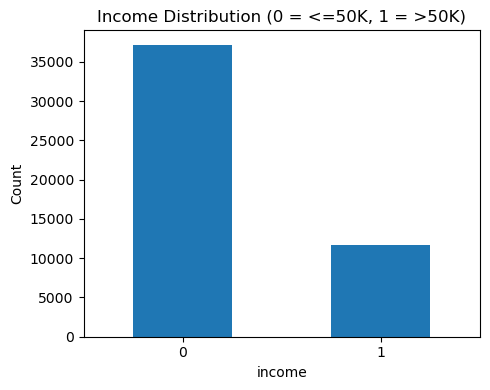

In [29]:

plt.figure(figsize=(5,4))
df["income"].value_counts().plot(kind="bar")
plt.title("Income Distribution (0 = <=50K, 1 = >50K)")
plt.ylabel("Count")
plt.xticks(rotation=0)
show_plot()


In [ ]:
10) Remove duplicates
    Duplicate rows were identified in the combined dataset.
    Duplicate entries can introduce bias and inflate model performance by repeating identical observations.
    All duplicate rows were removed to ensure data integrity and prevent skewed analysis.    

In [46]:

dup_before = df.duplicated().sum()
print("Duplicate rows BEFORE removal:", dup_before)

#plt.figure(figsize=(5,4))
#pd.Series({"Duplicates": dup_before, "Non-duplicates": df.shape[0]-dup_before}).plot(kind="bar")
#plt.title("Duplicate Rows (Before Removal)")
#plt.ylabel("Row count")
#plt.xticks(rotation=0)
#show_plot()


Duplicate rows BEFORE removal: 49


In [31]:

# Show duplicate examples (if any)
df[df.duplicated(keep=False)].head(10)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
2195,39,Private,184659,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,0
2303,90,Private,52386,Some-college,10,Never-married,Other-service,Not-in-family,Asian-Pac-Islander,Male,0,0,35,United-States,0
3118,19,Private,130431,5th-6th,3,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,36,Mexico,0
3445,41,Private,116391,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,40,United-States,1
3917,19,Private,251579,Some-college,10,Never-married,Other-service,Own-child,White,Male,0,0,14,United-States,0
4325,25,Private,308144,Bachelors,13,Never-married,Craft-repair,Not-in-family,White,Male,0,0,40,Mexico,0
4767,21,Private,250051,Some-college,10,Never-married,Prof-specialty,Own-child,White,Female,0,0,10,United-States,0
4881,25,Private,308144,Bachelors,13,Never-married,Craft-repair,Not-in-family,White,Male,0,0,40,Mexico,0
4940,38,Private,207202,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,48,United-States,1
5104,90,Private,52386,Some-college,10,Never-married,Other-service,Not-in-family,Asian-Pac-Islander,Male,0,0,35,United-States,0


In [32]:

rows_before = df.shape[0]
df = df.drop_duplicates()
rows_after = df.shape[0]
print("Rows removed:", rows_before - rows_after)


Rows removed: 53


In [ ]:
11) Outliers (IQR method) — detect + treat consistently
    Why Outlier Treatment is Needed Here?
      Outliers can:
        distort mean & variance
        stretch boxplots
        reduce model performance
        affect distance-based models (KNN, SVM)
        affect regression boundaries
    Outliers were detected in numerical features such as:
      - age, fnlwgt, education_num, capital_gain, capital_loss, hours_per_week
         We will use IQR:
                    Q1 = 25th percentile
                    Q3 = 75th percentile
                    IQR = Q3 − Q1
         Outliers often defined as values outside:
                   Lower bound = Q1 − 1.5 × IQR
                   Upper bound = Q3 + 1.5 × IQR
         Treatment:
                   IQR capping (keeps all rows)    
Using the Interquartile Range (IQR) method, extreme values lying beyond acceptable bounds were identified.
Instead of removing these observations (which may lead to data loss), IQR-based capping was applied to 
limit extreme values within the calculated range.
This helps reduce the influence of outliers while preserving the overall dataset.

    
Some other method to find the outlier:-
 - Z-score method:-
     When to use: Data is normally distributed
     Z-score checks how far a value is from the mean in units of standard deviation.
     [ z = \frac{x - \mu}{\sigma} ]
    Common rule:
    flag outliers where |z| > 3
    wWhat we can do:-
       compute z-scores on numeric columns
       count how many rows are flagged
       optionally remove those rows

Z-score treatment option: remove extreme rows
This is more aggressive than capping.
Use this when you believe extreme values are errors (not real).

   
    

In [33]:

numeric_cols = ["age","fnlwgt","education_num","capital_gain","capital_loss","hours_per_week"]
df[numeric_cols].describe()


,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,48789.000000,4.878900e+04,48789.000000,48789.000000,48789.000000,48789.000000
mean,38.653139,1.896697e+05,10.078809,1080.239829,87.597368,40.425895
std,13.708426,1.056182e+05,2.570072,7455.980728,403.213066,12.392856
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175550e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781400e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376080e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


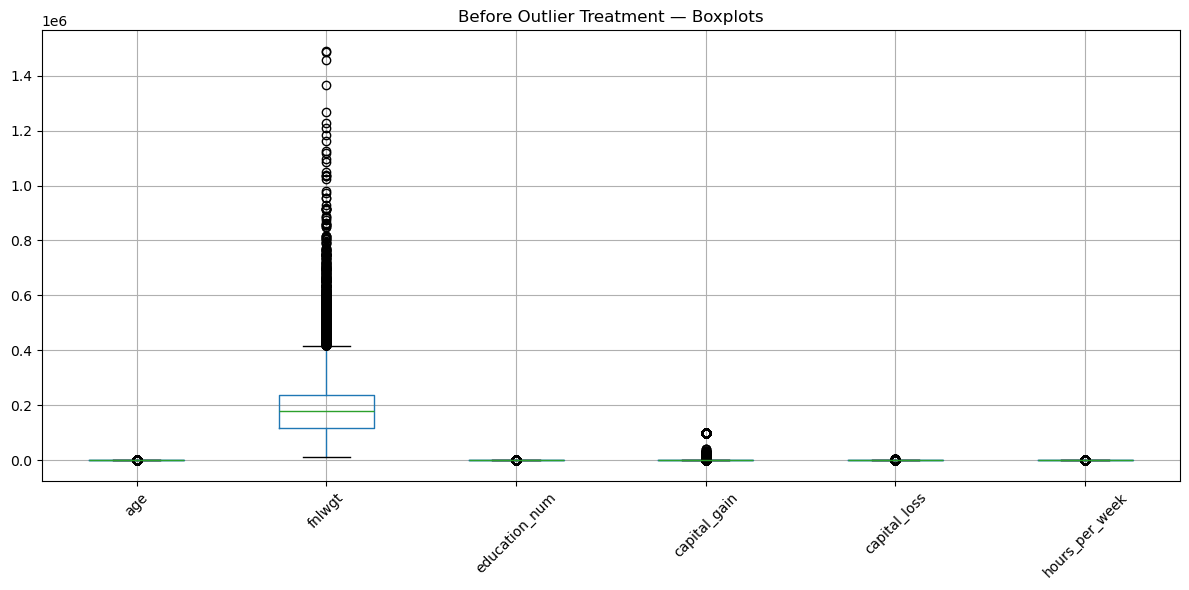

In [34]:

# BEFORE boxplot (overall)
plt.figure(figsize=(12,6))
df[numeric_cols].boxplot()
plt.xticks(rotation=45)
plt.title("Before Outlier Treatment — Boxplots")
show_plot()


In [35]:

def iqr_bounds(data, col, k=1.5):
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    iqr = q3 - q1
    return (q1 - k*iqr), (q3 + k*iqr)

# Outlier counts (before)
iqr_report = []
for col in numeric_cols:
    lo, hi = iqr_bounds(df, col)
    out_count = ((df[col] < lo) | (df[col] > hi)).sum()
    iqr_report.append((col, lo, hi, out_count))

iqr_table = pd.DataFrame(iqr_report, columns=["column","iqr_lower","iqr_upper","outlier_count"]).sort_values("outlier_count", ascending=False)
iqr_table


,column,iqr_lower,iqr_upper,outlier_count
5,hours_per_week,32.5,52.5,13486
3,capital_gain,0.0,0.0,4035
4,capital_loss,0.0,0.0,2282
2,education_num,4.5,16.5,1787
1,fnlwgt,-62524.5,417687.5,1453
0,age,-2.0,78.0,215


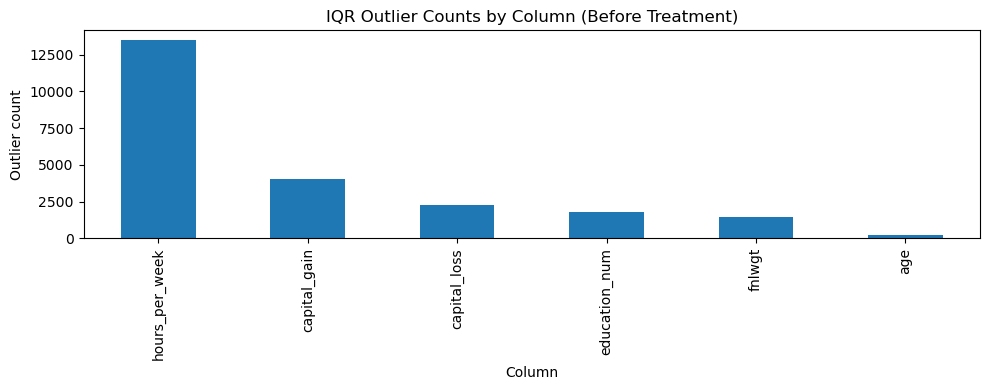

In [36]:

plt.figure(figsize=(10,4))
iqr_table.set_index("column")["outlier_count"].plot(kind="bar")
plt.title("IQR Outlier Counts by Column (Before Treatment)")
plt.ylabel("Outlier count")
plt.xlabel("Column")
show_plot()


In [37]:

# Save copy for before/after histograms
df_before_outliers = df.copy()

# Apply IQR capping:(Instead of deleting rows → limit values)
for col in numeric_cols:
    lo, hi = iqr_bounds(df, col)
    df[col] = df[col].clip(lower=lo, upper=hi)

df[numeric_cols].describe()


,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,48789.000000,48789.000000,48789.000000,48789.0,48789.0,48789.000000
mean,38.628338,186770.359128,10.122538,0.0,0.0,41.194265
std,13.629012,95326.067057,2.456714,0.0,0.0,6.185796
min,17.000000,12285.000000,4.500000,0.0,0.0,32.500000
25%,28.000000,117555.000000,9.000000,0.0,0.0,40.000000
50%,37.000000,178140.000000,10.000000,0.0,0.0,40.000000
75%,48.000000,237608.000000,12.000000,0.0,0.0,45.000000
max,78.000000,417687.500000,16.000000,0.0,0.0,52.500000


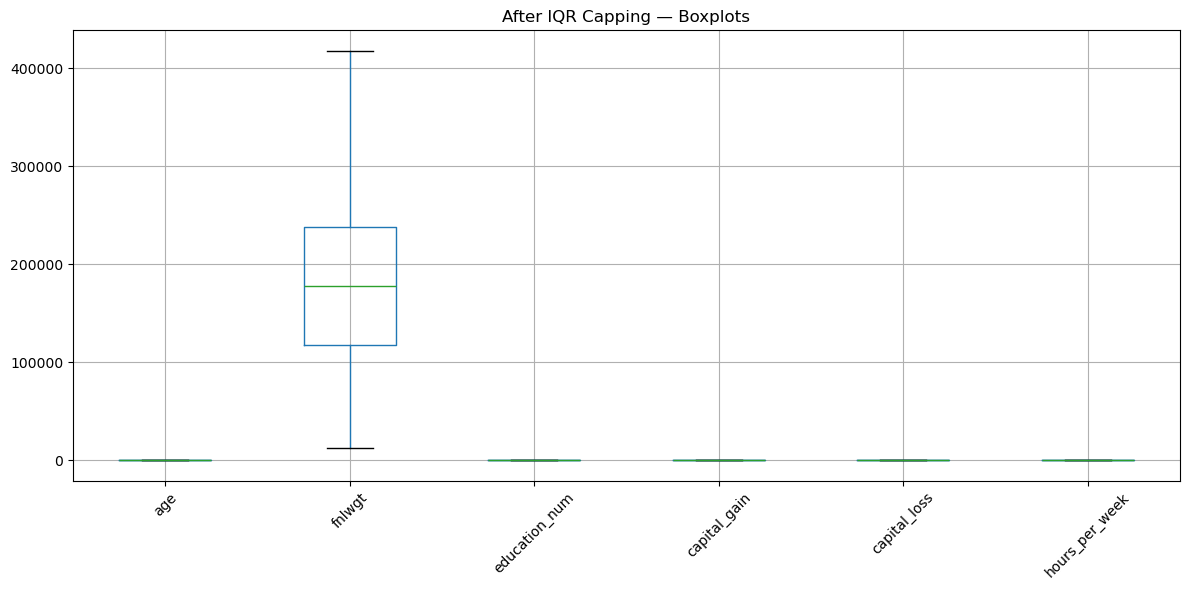

In [38]:

# AFTER boxplot (overall)
plt.figure(figsize=(12,6))
df[numeric_cols].boxplot()
plt.xticks(rotation=45)
plt.title("After IQR Capping — Boxplots")
show_plot()


In [ ]:
11.1 Extra visuals: histograms and per-column boxplots (Before vs After)

In [ ]:

for col in numeric_cols:
    plt.figure(figsize=(8,4))
    plt.hist(df_before_outliers[col].dropna(), bins=30, alpha=0.7, label="Before")
    plt.hist(df[col].dropna(), bins=30, alpha=0.7, label="After (IQR capped)")
    plt.title(f"Histogram — {col} (Before vs After IQR Capping)")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.legend()
    show_plot()


In [ ]:

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    plt.boxplot([df_before_outliers[col].dropna(), df[col].dropna()], labels=["Before", "After"])
    plt.title(f"Boxplot — {col} (Before vs After)")
    plt.ylabel(col)
    show_plot()
    

In [ ]:
12) Final dashboard (quick review)
   This section summarizes the final cleaned dataset:
    income distribution
    remaining missing values
    numeric boxplot
    a few key histograms


In [ ]:

# Dashboard: income distribution
plt.figure(figsize=(5,4))
df["income"].value_counts().plot(kind="bar")
plt.title("Dashboard: Income Distribution")
plt.ylabel("Count")
plt.xticks(rotation=0)
show_plot()

# Dashboard: remaining missing values
missing_after = df.isna().sum().sort_values(ascending=False)
missing_after_nonzero = missing_after[missing_after > 0]

plt.figure(figsize=(8,3))
if len(missing_after_nonzero) == 0:
    plt.text(0.01, 0.5, "No missing values remaining (NaN) ✅", fontsize=12)
    plt.axis("off")
else:
    missing_after_nonzero.plot(kind="bar")
    plt.title("Dashboard: Remaining Missing Values (NaN)")
    plt.ylabel("Missing count")
show_plot()

# Dashboard: numeric features
plt.figure(figsize=(12,5))
df[numeric_cols].boxplot()
plt.xticks(rotation=45)
plt.title("Dashboard: Numeric Features (After Cleaning)")
show_plot()

# Dashboard: key histograms
for col in ["age", "hours_per_week", "education_num"]:
    plt.figure(figsize=(8,4))
    df[col].hist(bins=30)
    plt.title(f"Dashboard: {col} Histogram (After Cleaning)")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    show_plot()


In [ ]:
13) Final validation checks 
    We check:
             shape
             missing values
             duplicate rows
             income labels are only 0/1

In [43]:

print("Final cleaned shape:", df.shape)

print("\nTop missing columns:")
print(df.isna().sum().sort_values(ascending=False).head(10))

print("\nDuplicate rows (should be 0):", df.duplicated().sum())

print("\nIncome value counts:")
print(df["income"].value_counts(dropna=False))


Final cleaned shape: (48789, 15)

Top missing columns:
age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
dtype: int64

Duplicate rows (should be 0): 49

Income value counts:
income
0    37108
1    11681
Name: count, dtype: int64


In [ ]:
14) Save final cleaned dataset

In [44]:

output_csv = "adult_combined_cleaned.csv"
df.to_csv(output_csv, index=False)
print("Saved:", output_csv)


Saved: adult_combined_cleaned.csv


In [ ]:
15.  Limitations of the Cleaning Process
  Despite thorough cleaning, certain limitations remain:

- Mode imputation for categorical variables may introduce bias if missing values are not truly random.
- Outlier treatment using IQR capping may reduce variability in the data and slightly distort the original distribution.
- Combining training and testing datasets prior to cleaning may introduce minor data leakage; however,
  this approach was adopted to ensure uniform preprocessing across the dataset as required by the assignment.
- Some features (e.g., capital_gain and capital_loss) are naturally skewed, and additional transformations
  may be required during feature engineering.
- The cleaning process does not address potential class imbalance in the target variable (income), which
  may need to be handled during model training.

In [ ]:
16. Future Improvements
Future enhancements to the preprocessing pipeline may include:

- Advanced imputation techniques such as KNN(K-Nearest Neighbors) or model-based imputation for missing categorical values.
- Robust scaling or transformation techniques (e.g., log transformation) for highly skewed numerical features.
- Separate preprocessing pipelines for training and testing datasets to eliminate any potential data leakage.
- Encoding of categorical variables using techniques such as One-Hot Encoding or Target Encoding.
- Addressing class imbalance using resampling techniques such as SMOTE or undersampling.

These improvements can further enhance model performance and generalizability in downstream predictive modeling tasks.

In [ ]:
17. Final Summary:-
 This notebook presents the data cleaning and preprocessing steps performed on the Adult Income dataset obtained from the
 UCI Machine Learning Repository. The objective of this task is to prepare a consistent and reliable dataset for further
 exploratory data analysis and predictive modeling.

 Both the training and testing datasets were first combined to ensure that all preprocessing steps were applied uniformly
 across the entire dataset. Initial inspection revealed several data quality issues, including missing values represented
 by the symbol "?", inconsistent categorical values caused by leading and trailing whitespace, and variations in the target 
 income labels within the test dataset.

 To address these issues, a systematic data cleaning approach was implemented. Missing categorical values were handled
 using mode imputation, whitespace inconsistencies were removed from all text-based features, and the income target
 variable was standardized and converted into a binary numerical format suitable for classification tasks. Duplicate
 records were identified and removed to maintain data integrity, and numerical features were examined for outliers 
 using the Interquartile Range (IQR) method. Detected outliers were treated through value capping to minimize their
 influence without discarding valid observations.

 Following these preprocessing steps, the cleaned dataset was validated to confirm the absence of missing values and duplicate
 entries. The resulting dataset is now consistent and ready for downstream tasks such as exploratory data analysis,
 feature engineering, and machine learning model development.